<a href="https://colab.research.google.com/github/Ghala-Alotaibi/data-analysis-projects/blob/main/Bike%20store%20analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline


# Load the dataset

In [2]:
import kagglehub
path = kagglehub.dataset_download("ahmedmohamedibrahim1/bike-sales-dataset")

100%|██████████| 127k/127k [00:00<00:00, 27.0MB/s]

Extracting files...


In [4]:
import os
import glob

# Find the Excel file inside the downloaded dataset folder
files = glob.glob(os.path.join(path, "*.xlsx"))
files

['/root/.cache/kagglehub/datasets/ahmedmohamedibrahim1/bike-sales-dataset/versions/1/Bike Sales Dashboard.xlsx']

# Read the dataset


In [6]:
sales = pd.read_excel(files[0])

sales.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Average of Income,Column Labels,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Count of Purchased Bike,Column Labels,NaN,NaN
2,Row Labels,No,Yes,Grand Total,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Row Labels,No,Yes,Grand Total
3,Female,53440,55774.058577,54580.777096,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,25,2,4,6
4,Male,56208.178439,60123.966942,58062.622309,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,26,8,8,16


In [7]:
sales.shape

(57, 37)

In [9]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 37 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   5 non-null      object 
 1   Unnamed: 1   5 non-null      object 
 2   Unnamed: 2   4 non-null      object 
 3   Unnamed: 3   4 non-null      object 
 4   Unnamed: 4   0 non-null      float64
 5   Unnamed: 5   0 non-null      float64
 6   Unnamed: 6   0 non-null      float64
 7   Unnamed: 7   0 non-null      float64
 8   Unnamed: 8   0 non-null      float64
 9   Unnamed: 9   0 non-null      float64
 10  Unnamed: 10  1 non-null      object 
 11  Unnamed: 11  8 non-null      object 
 12  Unnamed: 12  8 non-null      object 
 13  Unnamed: 13  7 non-null      object 
 14  Unnamed: 14  7 non-null      object 
 15  Unnamed: 15  0 non-null      float64
 16  Unnamed: 16  0 non-null      float64
 17  Unnamed: 17  0 non-null      float64
 18  Unnamed: 18  0 non-null      float64
 19  Unnamed: 1

In [10]:
sales.describe()

,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Cleaning the data


### checking all the sheets in the excel file

In [12]:

excel_file = files[0]

xls = pd.ExcelFile(excel_file)

xls.sheet_names


['Pivot Table', 'Dashboard', 'bike_buyers']

### Inspecting each sheet

In [13]:
for sheet in xls.sheet_names:
    temp = pd.read_excel(excel_file, sheet_name=sheet)

    print("\n----------------")
    print("Sheet:", sheet)
    print("Shape:", temp.shape)
    display(temp.head())


----------------
Sheet: Pivot Table
Shape: (57, 37)


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Average of Income,Column Labels,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Count of Purchased Bike,Column Labels,NaN,NaN
2,Row Labels,No,Yes,Grand Total,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Row Labels,No,Yes,Grand Total
3,Female,53440,55774.058577,54580.777096,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,25,2,4,6
4,Male,56208.178439,60123.966942,58062.622309,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,26,8,8,16



----------------
Sheet: Dashboard
Shape: (0, 1)


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Slicer List extension is not supported and will be removed
  warn(msg)


,Bike Sales Dashboard



----------------
Sheet: bike_buyers
Shape: (1000, 14)


,ID,Martial Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Age Brackets,Purchased Bike
0,12496,Married,Female,40000,1,Bachelors,Skilled Manual,Yes,0,0-1 Miles,Europe,42,Middle Age,No
1,24107,Married,Male,30000,3,Partial College,Clerical,Yes,1,0-1 Miles,Europe,43,Middle Age,No
2,14177,Married,Male,80000,5,Partial College,Professional,No,2,2-5 Miles,Europe,60,Old,No
3,24381,Single,Male,70000,0,Bachelors,Professional,Yes,1,5-10 Miles,Pacific,41,Middle Age,Yes
4,25597,Single,Male,30000,0,Bachelors,Clerical,No,0,0-1 Miles,Europe,36,Middle Age,Yes


In [14]:
sales = pd.read_excel(
    excel_file,
    sheet_name="bike_buyers"
)

sales.head()

,ID,Martial Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Age Brackets,Purchased Bike
0,12496,Married,Female,40000,1,Bachelors,Skilled Manual,Yes,0,0-1 Miles,Europe,42,Middle Age,No
1,24107,Married,Male,30000,3,Partial College,Clerical,Yes,1,0-1 Miles,Europe,43,Middle Age,No
2,14177,Married,Male,80000,5,Partial College,Professional,No,2,2-5 Miles,Europe,60,Old,No
3,24381,Single,Male,70000,0,Bachelors,Professional,Yes,1,5-10 Miles,Pacific,41,Middle Age,Yes
4,25597,Single,Male,30000,0,Bachelors,Clerical,No,0,0-1 Miles,Europe,36,Middle Age,Yes


In [17]:

sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ID                1000 non-null   int64 
 1   Martial Status    1000 non-null   object
 2   Gender            1000 non-null   object
 3   Income            1000 non-null   int64 
 4   Children          1000 non-null   int64 
 5   Education         1000 non-null   object
 6   Occupation        1000 non-null   object
 7   Home Owner        1000 non-null   object
 8   Cars              1000 non-null   int64 
 9   Commute Distance  1000 non-null   object
 10  Region            1000 non-null   object
 11  Age               1000 non-null   int64 
 12  Age Brackets      1000 non-null   object
 13  Purchased Bike    1000 non-null   object
dtypes: int64(5), object(9)
memory usage: 109.5+ KB


In [18]:
sales.shape


(1000, 14)

In [19]:

sales.columns

Index(['ID', 'Martial Status', 'Gender', 'Income', 'Children', 'Education',
       'Occupation', 'Home Owner', 'Cars', 'Commute Distance', 'Region', 'Age',
       'Age Brackets', 'Purchased Bike'],
      dtype='object')

## Handle missing values and duplicates



In [20]:
# isna() detects missing values such as NaN and None
sales.isna().sum().sort_values(ascending=False)

,0
ID,0
Martial Status,0
Gender,0
Income,0
Children,0
Education,0
Occupation,0
Home Owner,0
Cars,0
Commute Distance,0


In [21]:
sales.duplicated().sum()

np.int64(0)

In [22]:
sales[sales.duplicated()]

,ID,Martial Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Age Brackets,Purchased Bike


In [23]:
sales = sales.drop_duplicates()

## Rename columns for convenience

In [24]:
 sales.columns = (
    sales.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

sales.columns

Index(['id', 'martial_status', 'gender', 'income', 'children', 'education',
       'occupation', 'home_owner', 'cars', 'commute_distance', 'region', 'age',
       'age_brackets', 'purchased_bike'],
      dtype='object')

In [25]:
xls = pd.ExcelFile(files[0])
xls.sheet_names

['Pivot Table', 'Dashboard', 'bike_buyers']

In [26]:
for sheet in xls.sheet_names:
    temp = pd.read_excel(files[0], sheet_name=sheet)
    print(sheet, temp.shape)
    display(temp.head())

Pivot Table (57, 37)


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Average of Income,Column Labels,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Count of Purchased Bike,Column Labels,NaN,NaN
2,Row Labels,No,Yes,Grand Total,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Row Labels,No,Yes,Grand Total
3,Female,53440,55774.058577,54580.777096,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,25,2,4,6
4,Male,56208.178439,60123.966942,58062.622309,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,26,8,8,16


Dashboard (0, 1)


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Slicer List extension is not supported and will be removed
  warn(msg)


,Bike Sales Dashboard


bike_buyers (1000, 14)


,ID,Martial Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Age Brackets,Purchased Bike
0,12496,Married,Female,40000,1,Bachelors,Skilled Manual,Yes,0,0-1 Miles,Europe,42,Middle Age,No
1,24107,Married,Male,30000,3,Partial College,Clerical,Yes,1,0-1 Miles,Europe,43,Middle Age,No
2,14177,Married,Male,80000,5,Partial College,Professional,No,2,2-5 Miles,Europe,60,Old,No
3,24381,Single,Male,70000,0,Bachelors,Professional,Yes,1,5-10 Miles,Pacific,41,Middle Age,Yes
4,25597,Single,Male,30000,0,Bachelors,Clerical,No,0,0-1 Miles,Europe,36,Middle Age,Yes


In [27]:
sales = pd.read_excel(
    files[0],
    sheet_name="bike_buyers"
)

In [28]:
#df copy
df = sales.copy()

In [29]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

df.columns

Index(['id', 'martial_status', 'gender', 'income', 'children', 'education',
       'occupation', 'home_owner', 'cars', 'commute_distance', 'region', 'age',
       'age_brackets', 'purchased_bike'],
      dtype='object')

In [30]:
df.isna().sum()

,0
id,0
martial_status,0
gender,0
income,0
children,0
education,0
occupation,0
home_owner,0
cars,0
commute_distance,0


In [31]:
df.isna().sum().sort_values(ascending=False)

,0
id,0
martial_status,0
gender,0
income,0
children,0
education,0
occupation,0
home_owner,0
cars,0
commute_distance,0


In [32]:
df.duplicated().sum()

np.int64(0)

In [33]:
df["id"].duplicated().sum()

np.int64(0)

In [34]:
df[df.duplicated(keep=False)]

,id,martial_status,gender,income,children,education,occupation,home_owner,cars,commute_distance,region,age,age_brackets,purchased_bike


In [35]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print("\n", column)
    print(df[column].value_counts(dropna=False))


 martial_status
martial_status
Married    538
Single     462
Name: count, dtype: int64

 gender
gender
Male      511
Female    489
Name: count, dtype: int64

 education
education
Bachelors              306
Partial College        265
High School            179
Graduate Degree        174
Partial High School     76
Name: count, dtype: int64

 occupation
occupation
Professional      276
Skilled Manual    255
Clerical          177
Management        173
Manual            119
Name: count, dtype: int64

 home_owner
home_owner
Yes    683
No     317
Name: count, dtype: int64

 commute_distance
commute_distance
0-1 Miles             366
5-10 Miles            192
1-2 Miles             169
2-5 Miles             162
More than 10 Miles    111
Name: count, dtype: int64

 region
region
North America    508
Europe           300
Pacific          192
Name: count, dtype: int64

 age_brackets
age_brackets
Middle Age    701
Old           189
Adolescent    110
Name: count, dtype: int64

 purchased_bike
purch

In [37]:
for column in categorical_columns:
    df[column] = df[column].str.strip()

In [38]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print("\n", column)
    print(df[column].value_counts(dropna=False))


 martial_status
martial_status
Married    538
Single     462
Name: count, dtype: int64

 gender
gender
Male      511
Female    489
Name: count, dtype: int64

 education
education
Bachelors              306
Partial College        265
High School            179
Graduate Degree        174
Partial High School     76
Name: count, dtype: int64

 occupation
occupation
Professional      276
Skilled Manual    255
Clerical          177
Management        173
Manual            119
Name: count, dtype: int64

 home_owner
home_owner
Yes    683
No     317
Name: count, dtype: int64

 commute_distance
commute_distance
0-1 Miles             366
5-10 Miles            192
1-2 Miles             169
2-5 Miles             162
More than 10 Miles    111
Name: count, dtype: int64

 region
region
North America    508
Europe           300
Pacific          192
Name: count, dtype: int64

 age_brackets
age_brackets
Middle Age    701
Old           189
Adolescent    110
Name: count, dtype: int64

 purchased_bike
purch

In [39]:
df.describe()

,id,income,children,cars,age
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,19965.992000,56360.000000,1.898000,1.442000,44.163000
std,5347.333948,31085.635215,1.628572,1.125123,11.364488
min,11000.000000,10000.000000,0.000000,0.000000,25.000000
25%,15290.750000,30000.000000,0.000000,1.000000,35.000000
50%,19744.000000,60000.000000,2.000000,1.000000,43.000000
75%,24470.750000,70000.000000,3.000000,2.000000,52.000000
max,29447.000000,170000.000000,5.000000,4.000000,89.000000


## Visualize

### Purchases by gender

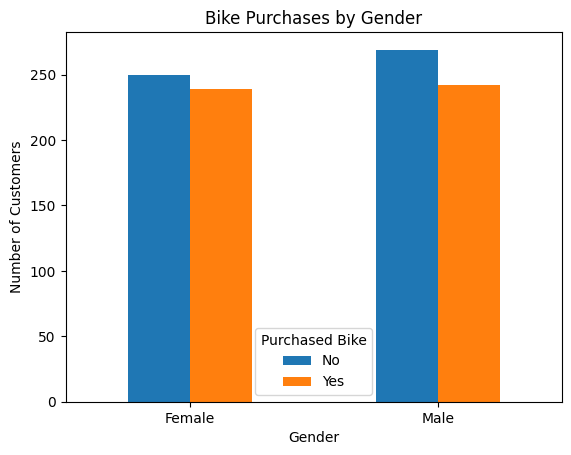

In [41]:
gender_purchase = pd.crosstab(
    df["gender"],
    df["purchased_bike"]
)

gender_purchase.plot(kind="bar")

plt.title("Bike Purchases by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Purchased Bike")
plt.show()

### Purchases by age group

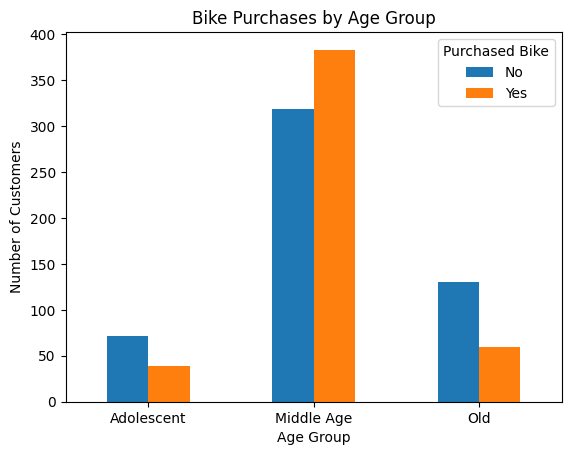

In [43]:
age_purchase = pd.crosstab(
    df["age_brackets"],
    df["purchased_bike"]
)

age_purchase.plot(kind="bar")

plt.title("Bike Purchases by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Purchased Bike")
plt.show()

### Income distribution

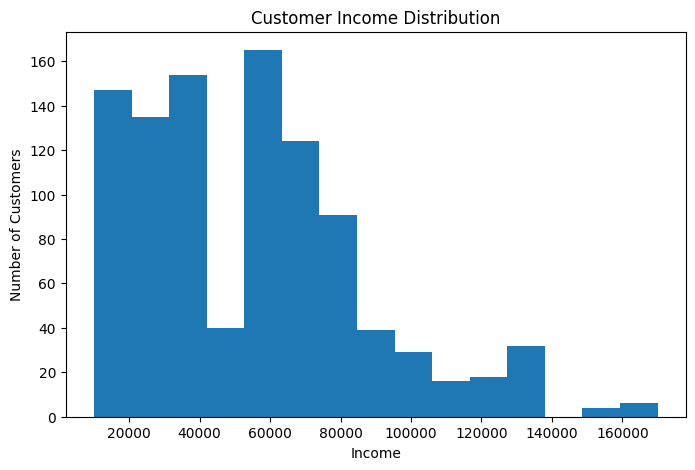

In [44]:
plt.figure(figsize=(8, 5))

plt.hist(df["income"], bins=15)

plt.title("Customer Income Distribution")
plt.xlabel("Income")
plt.ylabel("Number of Customers")

plt.show()

### Average income: buyers vs non-buyers

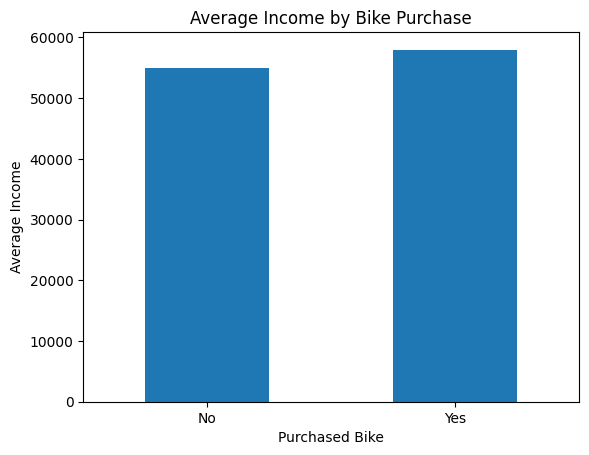

In [45]:
income_purchase = (
    df.groupby("purchased_bike")["income"]
      .mean()
)

income_purchase.plot(kind="bar")

plt.title("Average Income by Bike Purchase")
plt.xlabel("Purchased Bike")
plt.ylabel("Average Income")
plt.xticks(rotation=0)

plt.show()

### Purchases by commute distance

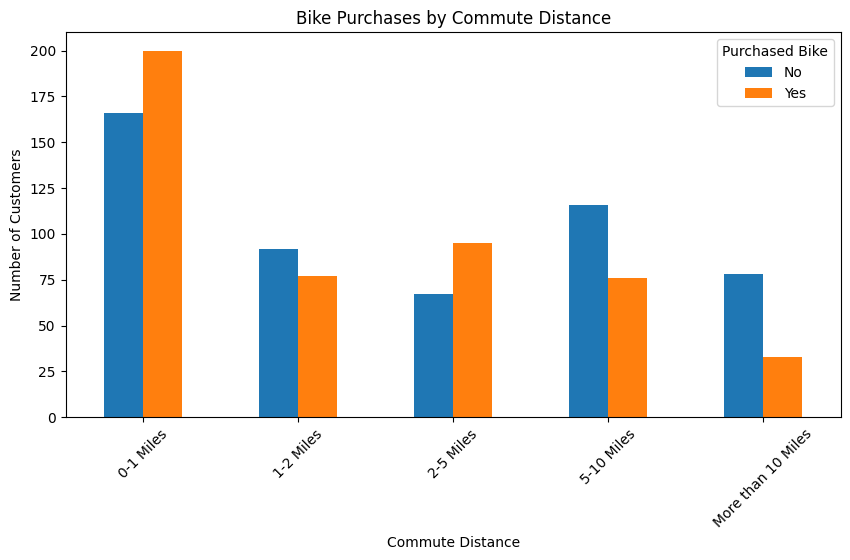

In [46]:
commute_purchase = pd.crosstab(
    df["commute_distance"],
    df["purchased_bike"]
)

commute_purchase.plot(kind="bar", figsize=(10, 5))

plt.title("Bike Purchases by Commute Distance")
plt.xlabel("Commute Distance")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.legend(title="Purchased Bike")

plt.show()

### By region

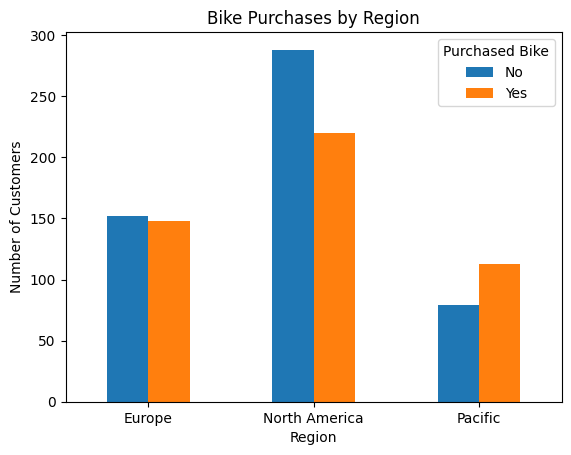

In [47]:
region_purchase = pd.crosstab(
    df["region"],
    df["purchased_bike"]
)

region_purchase.plot(kind="bar")

plt.title("Bike Purchases by Region")
plt.xlabel("Region")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Purchased Bike")

plt.show()



---




Middle-aged customers represent the largest customer segment in the dataset, which means they contribute the highest number of bike purchases overall. However, looking only at the total number of buyers can be misleading because this group also has the largest number of customers. To better understand purchasing behavior, it is important to calculate the purchase rate within each age group. This will show which age group is actually more likely to buy a bike, regardless of the size of the group. Comparing purchase percentages will provide a more accurate view of customer behavior and help identify the age segment with the strongest interest in bike purchases.